<a href="https://colab.research.google.com/github/ChinmoyBilhor/CardioPredict-Heart-Disease-Prediction-Using-Machine-Learning/blob/main/CardioPredict_Heart_Disease_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports**

In [1]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
!pip install -q catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


**Download Dataset**

In [2]:
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
print("Dataset path:", path)

100%|██████████| 12.4k/12.4k [00:00<00:00, 17.9MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/redwankarimsony/heart-disease-data/versions/6


**Load Dataset**

In [3]:
csv_file = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(csv_file)
print("First Five Records:")
print(df.head().to_string())

First Five Records:
   id  age     sex    dataset               cp  trestbps   chol    fbs         restecg  thalch  exang  oldpeak        slope   ca               thal  num
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True  lv hypertrophy   150.0  False      2.3  downsloping  0.0       fixed defect    0
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   True      1.5         flat  3.0             normal    2
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False  lv hypertrophy   129.0   True      2.6         flat  2.0  reversable defect    1
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False          normal   187.0  False      3.5  downsloping  0.0             normal    0
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False  lv hypertrophy   172.0  False      1.4    upsloping  0.0             normal    0


**Dataset Overview**

In [4]:
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Size: {df.size}")

Dataset Shape: (920, 16)
Dataset Size: 14720


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
print("Dataset Statistical Summary:")
df.describe(include="all")

Dataset Statistical Summary:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


**Missing Value Analysis**

In [7]:
missing_info = pd.DataFrame({"Available": df.notna().sum(), "Missing": df.isna().sum(),
                             "Missing (%)": (df.isna().mean()*100).round(2)})
missing_info = missing_info.sort_values(by = "Missing (%)", ascending = False)
print("Missing Value Summary:\n", missing_info)

Missing Value Summary:
           Available  Missing  Missing (%)
ca              309      611        66.41
thal            434      486        52.83
slope           611      309        33.59
fbs             830       90         9.78
oldpeak         858       62         6.74
trestbps        861       59         6.41
exang           865       55         5.98
thalch          865       55         5.98
chol            890       30         3.26
restecg         918        2         0.22
cp              920        0         0.00
dataset         920        0         0.00
id              920        0         0.00
age             920        0         0.00
sex             920        0         0.00
num             920        0         0.00


In [8]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 1759


**Feature Removal**

In [9]:
remove_cols = ["id", "ca", "thal"]
df.drop(columns = remove_cols, inplace = True)
print(f"Removed Features ({len(remove_cols)}): {remove_cols}")

Removed Features (3): ['id', 'ca', 'thal']


**Missing Value Imputation**

In [10]:
num_cols = ["chol", "thalch", "trestbps", "oldpeak"]
cat_cols = ["restecg", "exang", "fbs", "slope"]
num_imputer = SimpleImputer(strategy = "median")
cat_imputer = SimpleImputer(strategy = "most_frequent")
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [11]:
print(f"Total Missing Values After Imputation: {df.isna().sum().sum()}")

Total Missing Values After Imputation: 0


**Target Transformation**

In [12]:
print("Original Target Distribution:")
print(df["num"].value_counts())

Original Target Distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [13]:
df["num"] = (df["num"] > 0).astype(int)
print("Binary Target Distribution:")
print(df["num"].value_counts())

Binary Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


**Visualization**

**Heart Disease Class Distribution**

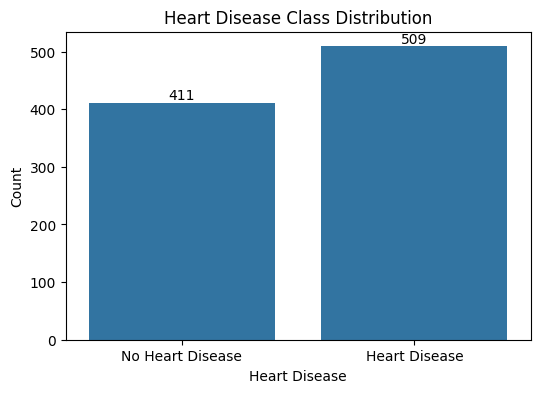

In [14]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data = df, x='num')
ax.bar_label(ax.containers[0])
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

**Age Distribution**

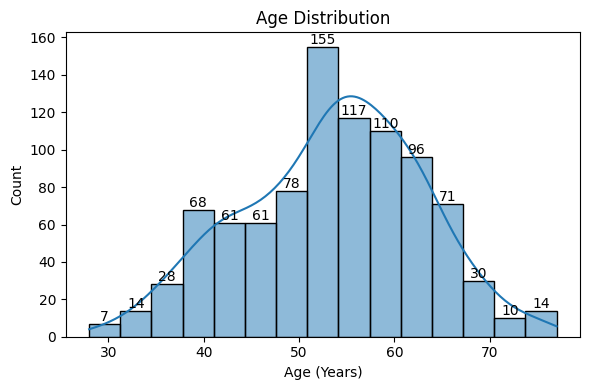

In [15]:
plt.figure(figsize=(6, 4))
ax = sns.histplot(data=df, x="age", bins=15, kde=True)
ax.bar_label(ax.containers[0])
plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Chest Pain Type vs Heart Disease**

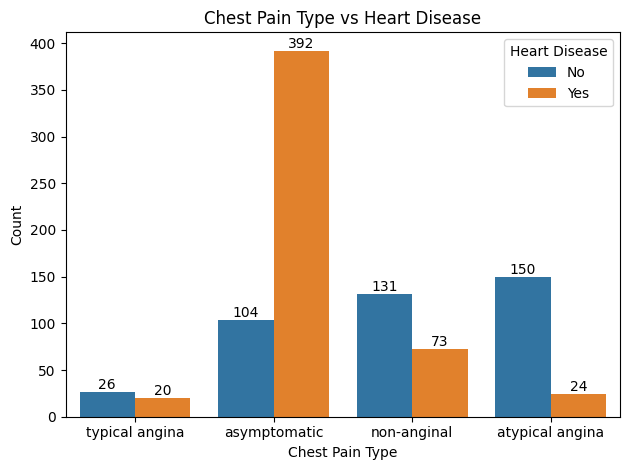

In [16]:
ax = sns.countplot(data = df, x="cp", hue="num")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

**Correlation Heatmap**

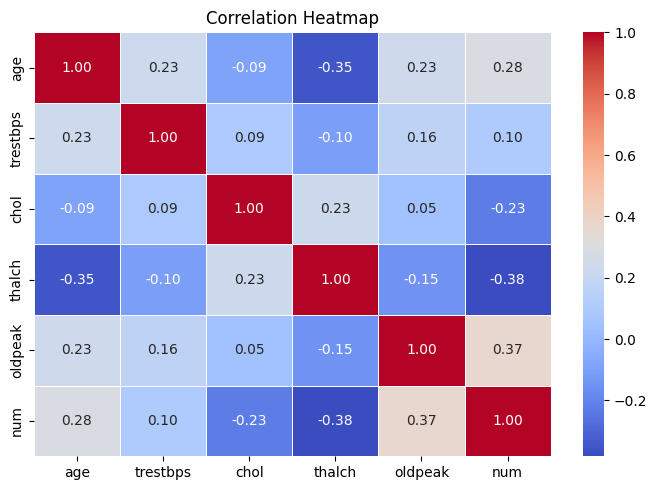

In [17]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "num"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True,
    cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Data Splitting**

In [18]:
X = df.drop(columns = ['num'])
y = df['num']
print("Shape of Features:", X.shape)
print("Shape of Target:", y.shape)

Shape of Features: (920, 12)
Shape of Target: (920,)


**Feature Encoding**

In [19]:
cat_cols = ["sex", "dataset", "cp", "restecg", "slope"]
X = pd.get_dummies(X, columns=cat_cols)
bool_cols = ["fbs", "exang"]
X[bool_cols] = X[bool_cols].astype(int)
print("Categorical features encoded successfully.")
print(f"Total Features After Encoding: {X.shape[1]}")

Categorical features encoded successfully.
Total Features After Encoding: 23


**Train-Test Split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape : {X_test.shape}")

Training Set Shape: (736, 23)
Testing Set Shape : (184, 23)


**Feature Scaling**

In [21]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [22]:
print("First Five Rows of Scaled Training Data:")
print(X_train.head().to_string())

First Five Rows of Scaled Training Data:
          age  trestbps      chol  fbs    thalch  exang   oldpeak  sex_Female  sex_Male  dataset_Cleveland  dataset_Hungary  dataset_Switzerland  dataset_VA Long Beach  cp_asymptomatic  cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_lv hypertrophy  restecg_normal  restecg_st-t abnormality  slope_downsloping  slope_flat  slope_upsloping
640 -0.063147  1.560270 -1.857816    0 -0.627205      1 -0.807883       False      True              False            False                 True                  False            False               False            True              False                    True           False                     False              False        True            False
743  2.180526 -0.116411 -1.857816    0  0.087627      0 -0.335827       False      True              False            False                False                   True            False               False            True              False            

**Model Training**

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [24]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
    max_depth=3, eval_metric="logloss", tree_method="hist", random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [25]:
cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1,
      task_type="GPU", devices="0",
      random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
print("CatBoost model trained successfully.")

CatBoost model trained successfully.


**Model Evaluation**

In [26]:
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model}
first = True
for name, model in models.items():
    y_pred = model.predict(X_test)
    if not first:
      print()
    first = False
    print(f"{name} Performance:")

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

Random Forest Performance:
Accuracy: 0.8587
Precision: 0.8393
Recall: 0.9216
F1-Score: 0.8785
Confusion Matrix:
[[64 18]
 [ 8 94]]

XGBoost Performance:
Accuracy: 0.8315
Precision: 0.8318
Recall: 0.8725
F1-Score: 0.8517
Confusion Matrix:
[[64 18]
 [13 89]]

CatBoost Performance:
Accuracy: 0.8043
Precision: 0.8056
Recall: 0.8529
F1-Score: 0.8286
Confusion Matrix:
[[61 21]
 [15 87]]
